In [21]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import json
import matplotlib.image as image

In [22]:
sys.path.insert(1, 'utils/')

In [23]:
#from load_data import *
# from plot_functions import *
from utils_functions import *

# FIGURE 2 or 3
Change the figure parameter accordingly

In [30]:
figure = 3
network = 'M2'
save_name =f'Figure_{figure}'
save = True
circuit_scheme = f'schemes/scheme_{network}_figure{figure}.png'

In [31]:
def extract_source_data(ax,save_name,panel):

    lines = ax.get_lines()
    df = pd.DataFrame()
    
    for line in lines:

        try:
            lab = line.get_label()
            x = line.get_xdata()
            y = line.get_ydata()
            df[f'{lab}_x'] = x
            df[f'{lab}_y'] = y
        except:
            None

    df.to_csv(f'source_data/{save_name}{panel}.csv')


## Load Simulation Results

In [32]:

fn = 12
      
if figure == 3:
    #simulation_fixed = load_dict(f'data/simulation_osr_fixed_{fn}.pickle')
    simulation_fixed =  load_dict(f'../output/params_final_nonlin_fixed/simulation_osr_{fn}.pickle')

elif figure == 2:
    #simulation_fixed = load_dict(f'data/simulation_osr_dynamic_{fn}_strychnine.pickle')
    simulation_fixed =  load_dict(f'../output/params_final_nonlin_strych/simulation_osr_{fn}.pickle')

#simulation_dynamic = load_dict(f'data/simulation_osr_dynamic_{fn}.pickle')
simulation_dynamic = load_dict(f'../output/params_final_nonlin/simulation_osr_{fn}.pickle')





keys = ['6_Hz', '12_Hz', '16_Hz']

frequencies = simulation_dynamic['osrparams']['frequencies']
periods = np.round(1/frequencies,2)*1000

times = [simulation_dynamic['simulations'][key]['time']-simulation_dynamic['simulations'][key]['lastflash_tp']
         for key in keys]
#time2 = simulation2['simulations'][key]['time']

flashes =[np.where(np.diff(simulation_dynamic['simulations'][key]['stimulus']) != 0)[0].tolist() for key in keys]

lastflashends = [simulation_dynamic['simulations'][key]['lastflash_tp'] for key in keys]
#lastflashend2 = simulation2['simulations'][key]['lastflash_tp']


# simulation dynamic
responses_dynamic = [simulation_dynamic['simulations'][key]['RG'] for key in keys]
delays_dynamic = [simulation_dynamic['simulations'][key]['delay'] for key in keys]
peak_amps_dynamic = [simulation_dynamic['simulations'][key]['peak_amplitude'] for key in keys]

delays_all_dynamic = simulation_dynamic['delays']*1000
slope_dynamic = simulation_dynamic['slope']
offset_dynamic =  simulation_dynamic['offset']*1000 

delays_all_dynamic_relative = delays_all_dynamic - delays_all_dynamic[-1]
offset_dynamic_relative =  simulation_dynamic['offset']*1000 - delays_all_dynamic[-1]


# simulation fixed
responses_fixed = [simulation_fixed['simulations'][key]['RG'] for key in keys]
delays_fixed = [simulation_fixed['simulations'][key]['delay'] for key in keys]
peak_amps_fixed = [simulation_fixed['simulations'][key]['peak_amplitude'] for key in keys]

delays_all_fixed = simulation_fixed['delays']*1000
slope_fixed = simulation_fixed['slope']
offset_fixed =  simulation_fixed['offset']*1000

delays_all_fixed_relative = delays_all_fixed - delays_all_dynamic[-1]
offset_fixed_relative =  simulation_fixed['offset']*1000 - delays_all_dynamic[-1]

# load circuit image
circuit_scheme = image.imread(circuit_scheme)


omitted_flashstarts = [0.16-0.04, 0.10-0.04, 0.06-0.04]
omitted_flashends = [i+0.04 for i in omitted_flashstarts]

## Plot

/tmp/ipykernel_2280961/528983704.py:230: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([cond_labels[0], cond_labels[1]])


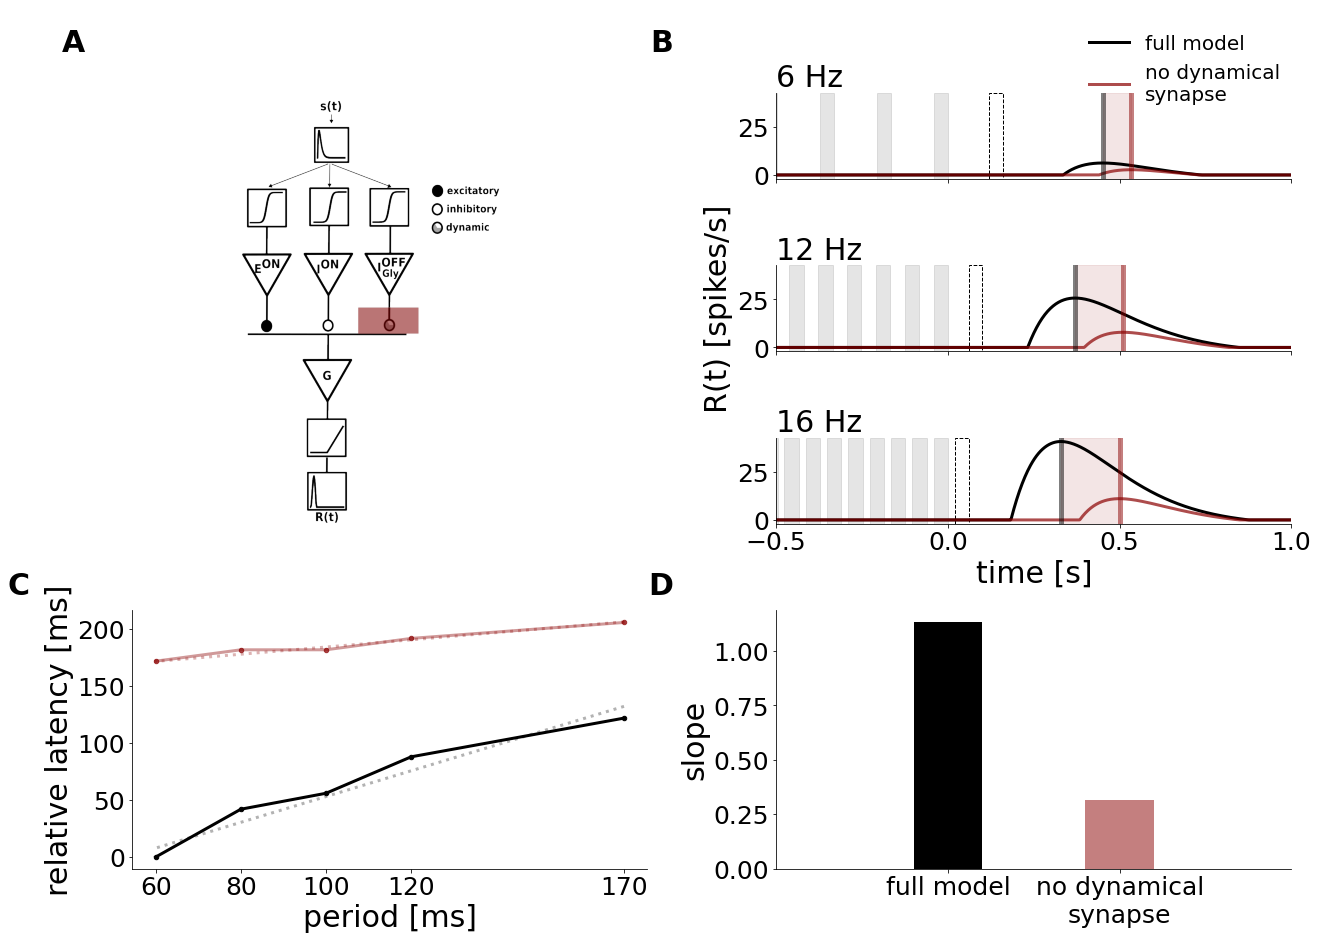

In [33]:


#figure parameter

fontsize_legend = 20
fontsize_labels = 30
fontsize_panellabel = 30
fontsize_ticks = 25
lw = 3
ms = 20
panellabel_position = [-0.2, 1.15]
frequencytext_position = [0.15,1.1]
figsize_ratio = 5
nrows = 5
ncols = 2

# figsize = (ncols*figsize_ratio, nrows*figsize_ratio)
figsize = (20,14)

show = True
image_format = "png"
dpi = 300

if figure == 2:
    cond_labels = ["full model", "no glycinergic\namacrine cell"]
    color_test = "red"

elif figure == 3:
    cond_labels = ["full model", "no dynamical\nsynapse"]
    color_test = "darkred"

    
frequencies_displayed = [6,12,16]
    
color_control = "k"
alpha_test = .7

#initialize figure
fig = plt.figure(figsize=figsize)
gs = fig.add_gridspec(nrows,ncols)
fig.tight_layout()

fig.patch.set_facecolor('white')


fig.subplots_adjust(top=0.88,
bottom=0.11,
left=0.145,
right=0.95,
hspace=1,
wspace=0.25)


#####################################################################################################################
# create panels
#####################################################################################################################

A = fig.add_subplot(gs[0:3,0], frameon = False)

B = fig.add_subplot(gs[0,1], frameon = False)
B0 = fig.add_subplot(gs[0,1])
B1 = fig.add_subplot(gs[1,1], sharey = B0, sharex = B0)
B2 = fig.add_subplot(gs[2,1], sharey = B0, sharex = B0)

C = fig.add_subplot(gs[3:,0])

D = fig.add_subplot(gs[3:,1])



#####################################################################################################################
# PANEL A
#####################################################################################################################

if "A" in globals():
    ax = A
    
    ax.text(panellabel_position[0]-0.3,panellabel_position[1]+0, 'A', transform=ax.transAxes,
          fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')
    
    ax.set_xticks([])
    ax.set_yticks([])

    ax.imshow(circuit_scheme)
    
#####################################################################################################################
# PANEL B
#####################################################################################################################

if "B" in globals():
    ax = B
    ax.text(panellabel_position[0]-0,panellabel_position[1]+0.6, 'B', transform=ax.transAxes,
          fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')
    
    ax.set_xticks([])
    ax.set_yticks([])

    panellabels = ['B0', 'B1', 'B2']
#####################################################################################################################
# COMMON TO SUBPANELS B0,B1,B2
#####################################################################################################################
index_frequencies_to_show = [0,2,4]
    
for index, ax in enumerate([B0,B1,B2]):
    
    panel = panellabels[index]

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    ax.set_title(f'{frequencies_displayed[index]} Hz',fontsize = fontsize_labels, loc = 'left')
    
    if ax == B0:
        ax.plot(times[index],responses_dynamic[index], color = 'black', linewidth = lw, label = cond_labels[0])
        ax.plot(times[index],responses_fixed[index], color = color_test, alpha=.7, linewidth = lw, label = cond_labels[1])
    else:
        ax.plot(times[index],responses_dynamic[index], color = 'black', linewidth = lw,label = f"_{cond_labels[0]}")
        ax.plot(times[index],responses_fixed[index], color = color_test, alpha=.7, linewidth = lw, label = f"_{cond_labels[1]}")
    
    for f in range(len(flashes[0])):  
        if  not f % 2 :
            ax.axvspan(times[index][flashes[index][f]], times[index][flashes[index][f+1]+1], color = 'k', alpha = 0.1)
            
    ax.axvspan(omitted_flashstarts[index], omitted_flashends[index], edgecolor = "k", facecolor="w", linestyle = '--')

            
    ax.locator_params(axis='y', nbins=3)
    ax.set_xlim(-.5,1)
    
    # plot max and span
#     ax.scatter(delays_dynamic[index],peak_amps_dynamic[index], color = 'k')
#     ax.scatter(delays_fixed[index],peak_amps_fixed[index], color = 'grey')

    ax.axvline(delays_dynamic[index], color = 'k', alpha = .5, linewidth = 5 )
    ax.axvline(delays_fixed[index], color = color_test, alpha = .5,linewidth = 5)

    ax.axvspan(delays_dynamic[index],delays_fixed[index], color = color_test, alpha = 0.1)
    ax.locator_params(axis='x', nbins=3)
    ax.locator_params(axis='y', nbins=2)


    ax.tick_params('x', labelsize=fontsize_ticks)
    ax.tick_params('y', labelsize=fontsize_ticks)

    extract_source_data(ax,save_name,panel)

    


#####################################################################################################################
# SUBPANEL B0 specific
#####################################################################################################################

ax = B0

ax.tick_params('x', labelbottom=False)
    
#####################################################################################################################
# SUBPANEL B1
#####################################################################################################################

ax = B1
ax.tick_params('x', labelbottom=False)
ax.set_ylabel('R(t) [spikes/s]',fontsize = fontsize_labels)

    
#####################################################################################################################
# SUBPANEL B2
#####################################################################################################################

ax = B2
ax.set_xlabel('time [s]',fontsize = fontsize_labels)


#####################################################################################################################
# PANEL C
#####################################################################################################################
if "C" in globals():
    ax = C
    panel = 'C'
    ax.text(*panellabel_position, 'C', transform=ax.transAxes,
      fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')
    
    
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    
    ax.set_ylabel('relative latency [ms]', fontsize = fontsize_labels)
    ax.set_xlabel('period [ms]', fontsize = fontsize_labels)
    
    ax.set_xticks(periods[::-1])
    
    
    ax.plot(periods,delays_all_dynamic_relative,color = 'black',linewidth = lw, label =f'_{cond_labels[0]}')
    ax.scatter(periods,delays_all_dynamic_relative, color = 'black', s = ms)

    ax.plot(periods,delays_all_fixed_relative,color = color_test, alpha=.4,linewidth = lw, label = f'_{cond_labels[1]}')
    ax.scatter(periods,delays_all_fixed_relative, color = color_test, alpha=.7, s = ms)

    # slope fit 
    ax.plot(periods,slope_fun(periods,slope_fixed,offset_fixed_relative),
           color = color_test,linestyle = ':',linewidth = lw,alpha = 0.3, label = f'_{cond_labels[0]}')
#            label = f'slope: {slope_fixed:.2f}')

    ax.plot(periods,slope_fun(periods,slope_dynamic,offset_dynamic_relative),
           color = 'black',linestyle = ':',linewidth = lw,alpha = 0.3, label = f'_{cond_labels[1]}')
#            label = f'slope: {slope_dynamic:.2f}')


#     ax.legend(fontsize = fontsize_legend)
    ax.tick_params('x', labelsize=fontsize_ticks)
    ax.tick_params('y', labelsize=fontsize_ticks)

    extract_source_data(ax,save_name,panel)


#####################################################################################################################
# PANEL C
#####################################################################################################################
if "D" in globals():
    ax = D
    ax.text(*panellabel_position, 'D', transform=ax.transAxes,
      fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')
    
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
#     ax.spines['bottom'].set_visible(False)
    # Label the axis
    ax.set_ylabel('slope',fontsize = fontsize_labels)

    ax.set_xticklabels([cond_labels[0], cond_labels[1]])
    
    ax.bar(cond_labels[0],slope_dynamic, width=0.4, color='k')
    ax.bar(cond_labels[1], slope_fixed, width=0.4, color=color_test, alpha=.5)
    
    ax.tick_params('x', labelsize=fontsize_ticks)
    ax.tick_params('y', labelsize=fontsize_ticks)
    
    ax.set_xlim(-1,2)
    
#####################################################################################################################
# LEGEND
#####################################################################################################################
     
if figure == 2:
    fig.legend(fontsize = fontsize_legend, frameon=False,loc=(.82,.88))
elif figure ==3:
    fig.legend(fontsize = fontsize_legend, frameon=False,loc=(.82,.88))
    
#####################################################################################################################
# SAVE AND PLOT
#####################################################################################################################
   
if save:
    plt.savefig("../Figures/{}.{}".format(save_name, image_format))
if show:
    plt.show()
else:
    plt.close()

In [34]:
slope_dynamic, slope_fixed

(1.1315021425086438, 0.315965655949165)

In [35]:
save_name

'Figure_3'